# Why MMAR? Gaussian Tails vs. a Posterior Predictive Fit

A 256-day COVID-era window compares VOO's absolute daily log-returns with a Gaussian maximum-likelihood fit and the univariate MMAR posterior predictive distribution.

In [1]:
from pathlib import Path

import bayesflow as bf
import keras

from mmar import univariate as model, viz
from mmar.data import load_market_returns
from mmar.viz import univariate as plots

INFO:bayesflow:Multiple Keras-compatible backends detected (JAX, PyTorch, TensorFlow). Defaulting to JAX.
To override, set the KERAS_BACKEND environment variable before importing bayesflow.
See: https://keras.io/getting_started/#configuring-your-backend
INFO:jax._src.xla_bridge:Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
INFO:bayesflow:Using backend 'jax'


In [2]:
TICKER = "VOO"
MODEL_PATH = Path("checkpoints/univariate/model.keras")
COVID_WINDOW_END = "2021-01-07"
N_POSTERIOR_SAMPLES = 5_000
FIGURES_DIR = Path("figures/motivation")

viz.configure_plot_style()

In [3]:
market_returns = load_market_returns(
    ("VOO", "GLD", "TLT"), start="2015-01-01", end="2026-09-01",
)

voo_returns = market_returns.loc[:COVID_WINDOW_END, TICKER].tail(model.WINDOW)

In [4]:
approximator = keras.saving.load_model(MODEL_PATH)

In [5]:
samples = approximator.sample(
    conditions={"returns": voo_returns.to_numpy()[None, :, None]},
    num_samples=N_POSTERIOR_SAMPLES,
    seed=42
)

posterior = model.stack_samples({name: samples[name] for name in model.PARAMETER_NAMES})
posterior_paths = model.posterior_resimulations(posterior, seed=47)[0]

Summarizing:   0%|          | 0/1 [00:00<?, ?batch/s]

Sampling:   0%|          | 0/1 [00:00<?, ?batch/s]

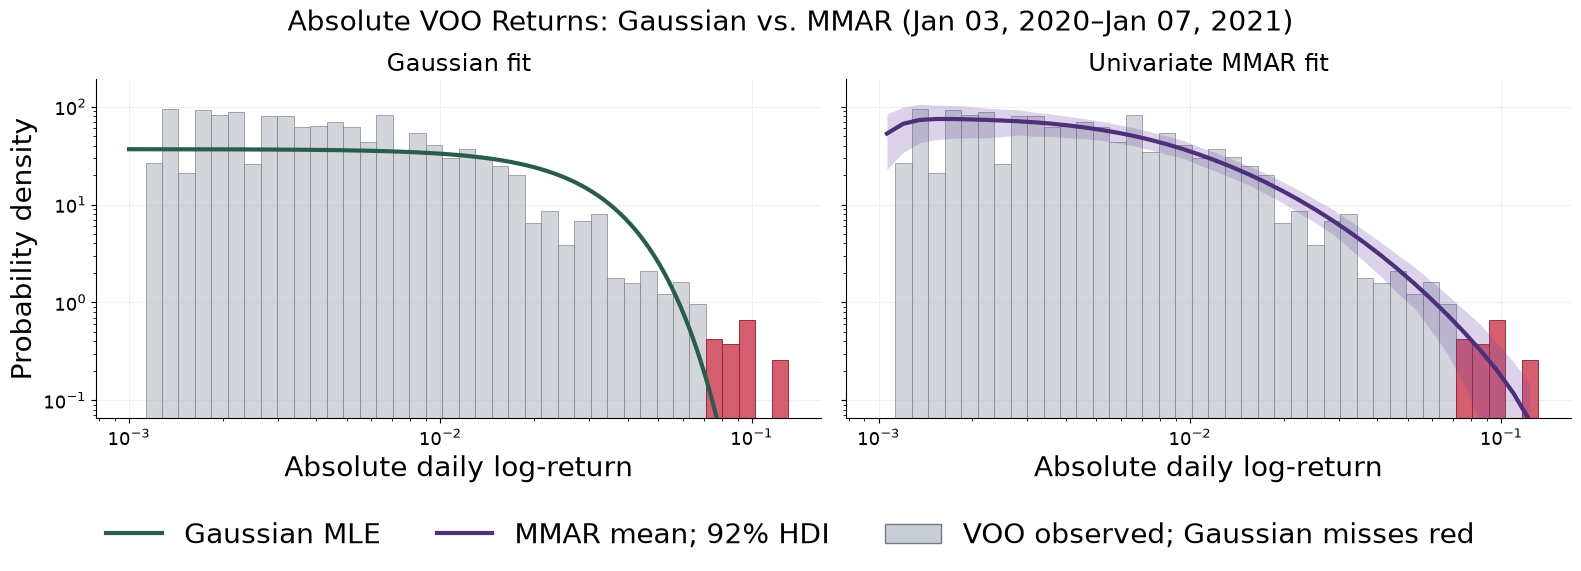

In [6]:
fig = plots.plot_gaussian_mmar_fit_comparison(
    voo_returns, posterior_paths, ticker=TICKER, n_bins=40,
    x_label_fontsize=20, y_label_fontsize=20, legend_fontsize=20,
    uncertainty_style="hdi_band", uncertainty_probability=0.92,
    density_smoothing=1.5, density_clip=1e-3, minimum_magnitude=1e-3,
)
_ = viz.save_figure(fig, "voo_gaussian_vs_mmar_covid.png", FIGURES_DIR)

Both panels use the same 256 observations and the same absolute-return histogram, restricted to magnitudes of at least $10^{-3}$. The dark-green Gaussian MLE uses the mean and standard deviation of all signed log-returns and is folded to $f(x)+f(-x)$ for $x>0$. Ordinary observations are gray; red bars lie beyond its central 99% range. On the right, each posterior-predictive density is lightly smoothed over adjacent log-spaced bins; the solid purple line is their pointwise mean and the shaded region is the narrowest 92% interval. Densities below $10^{-3}$ are masked on the log scale.